In [6]:
# Run the visualization script
import subprocess
import os
from pathlib import Path

# Create output directory
outdir = 'figs/zinc12k_evaluation_default'
os.makedirs(outdir, exist_ok=True)

# Run visualization
cmd = [
    'python', 'visualize_latent_embeddings.py',
    '--embedding', 'scripts/final_logs/ZINC12K_regress_nokld_2025-12-31-20-31-47/ordered_embedding_ZINC12K_regress_nokld.npy',
    '--labels', 'scripts/final_logs/ZINC12K_regress_nokld_2025-12-31-20-31-47/embedding_prop_lists_ZINC12K_regress_nokld.npy',
    '--outdir', outdir,
    '--no-show'
]

print("Running visualization script (Default, α=0.01, 14 node features)...")
print(f"Command: {' '.join(cmd)}")
print()

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors/Warnings:")
    print(result.stderr)

if result.returncode == 0:
    print("\n✅ Visualization complete!")
    print(f"Figures saved to: {outdir}")
    
    fig_files = list(Path(outdir).glob('*.png'))
    if fig_files:
        print("\nGenerated figures:")
        for f in sorted(fig_files):
            print(f"  - {f.name}")
else:
    print(f"\n❌ Visualization failed with return code {result.returncode}")


Running visualization script (Default, α=0.01, 14 node features)...
Command: python visualize_latent_embeddings.py --embedding scripts/final_logs/ZINC12K_regress_nokld_2025-12-31-20-31-47/ordered_embedding_ZINC12K_regress_nokld.npy --labels scripts/final_logs/ZINC12K_regress_nokld_2025-12-31-20-31-47/embedding_prop_lists_ZINC12K_regress_nokld.npy --outdir figs/zinc12k_evaluation_default --no-show



KeyboardInterrupt: 

Found 8 figure(s):

📊 latent_pca_prop1.png


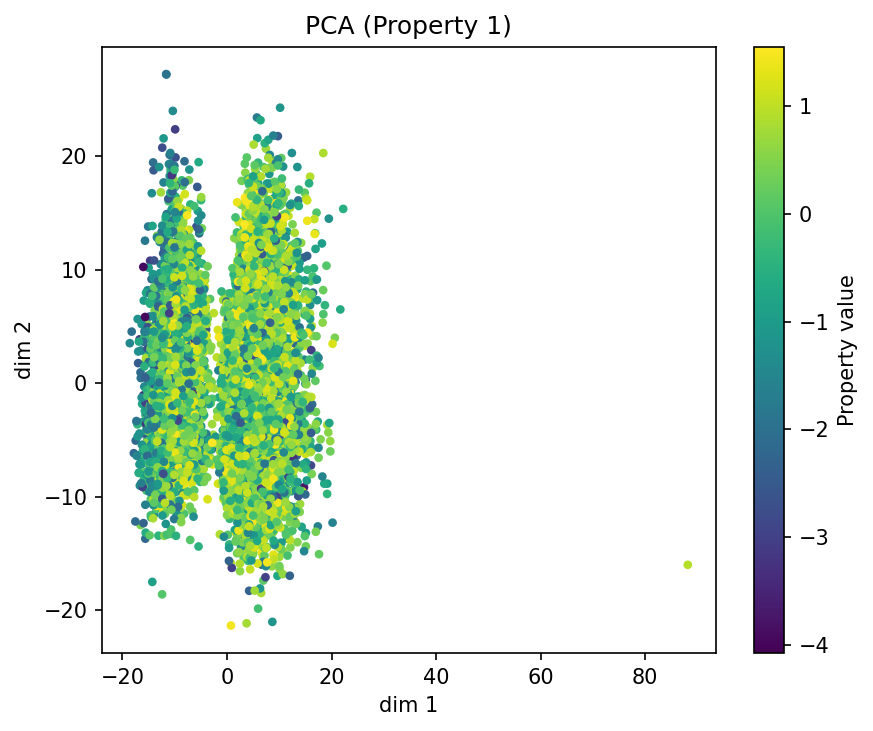


📊 latent_pca_prop2.png


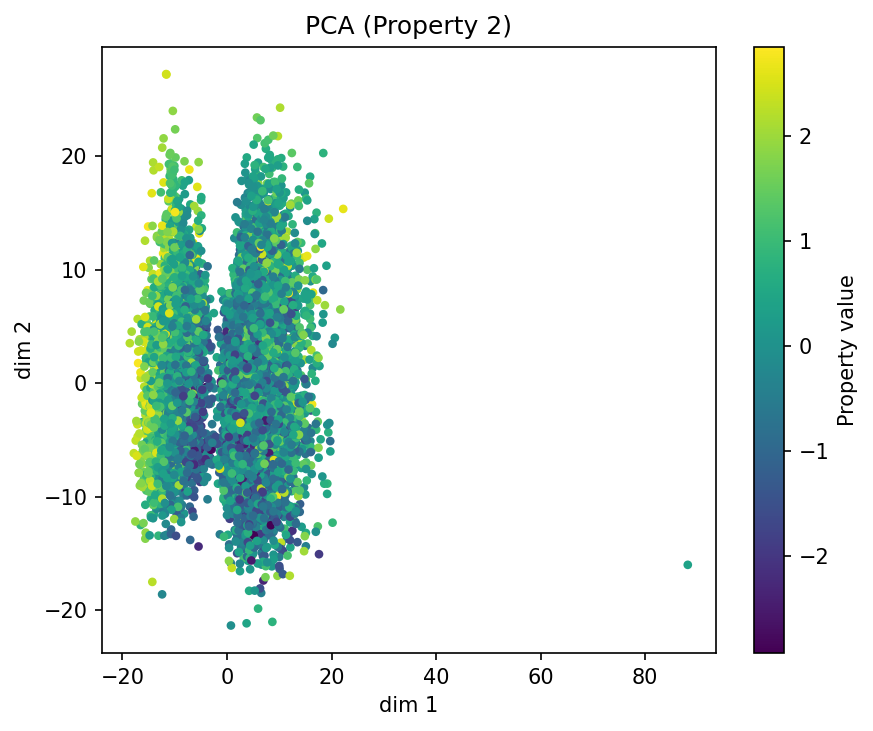


📊 latent_pca_prop3.png


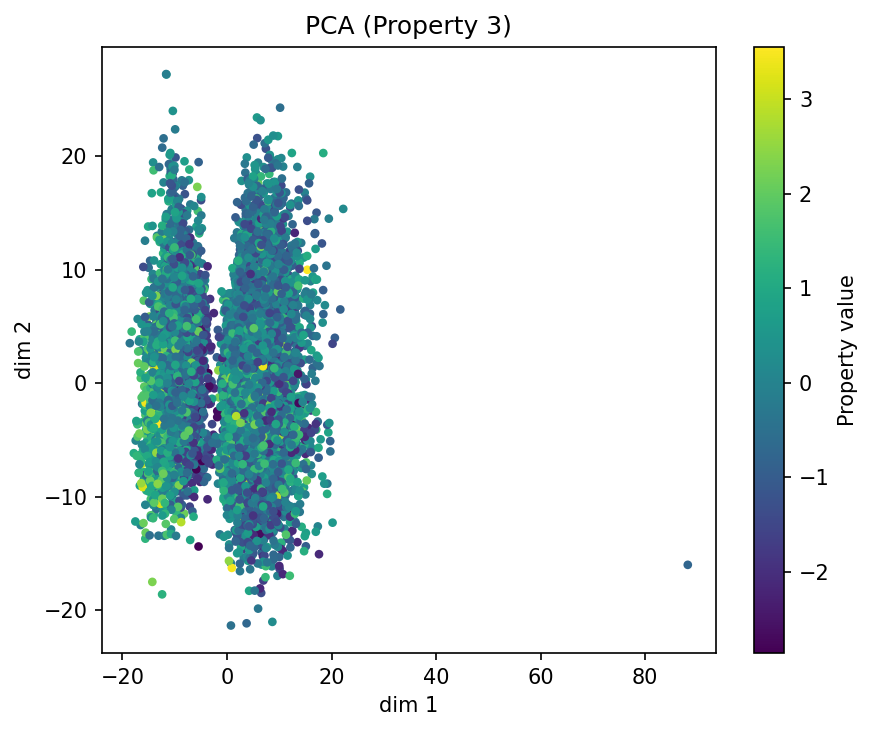


📊 latent_pca_prop4.png


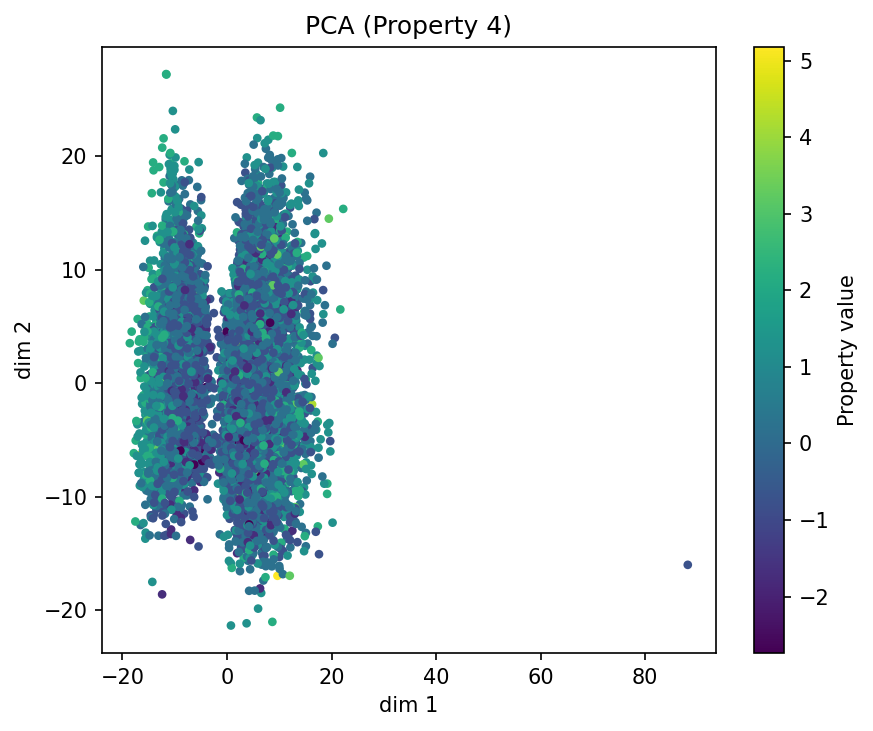


📊 latent_phate_prop1.png


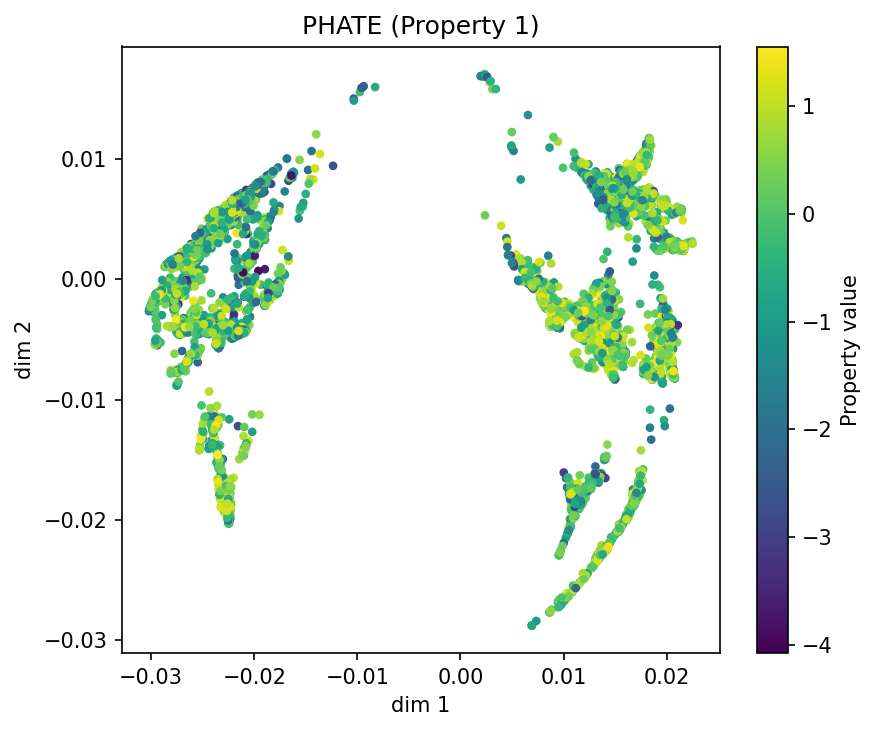


📊 latent_phate_prop2.png


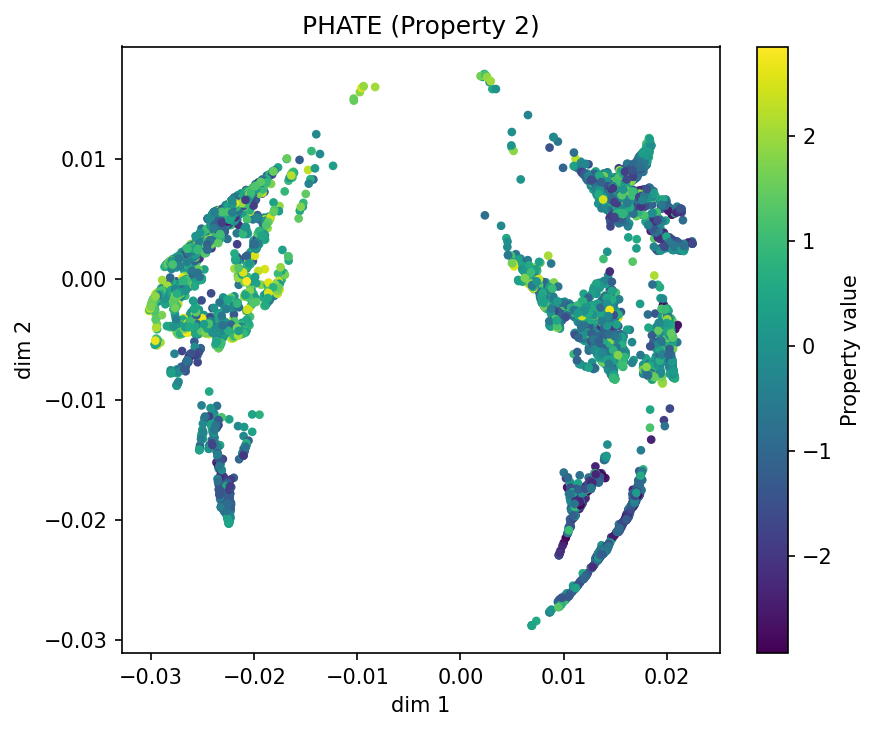


📊 latent_phate_prop3.png


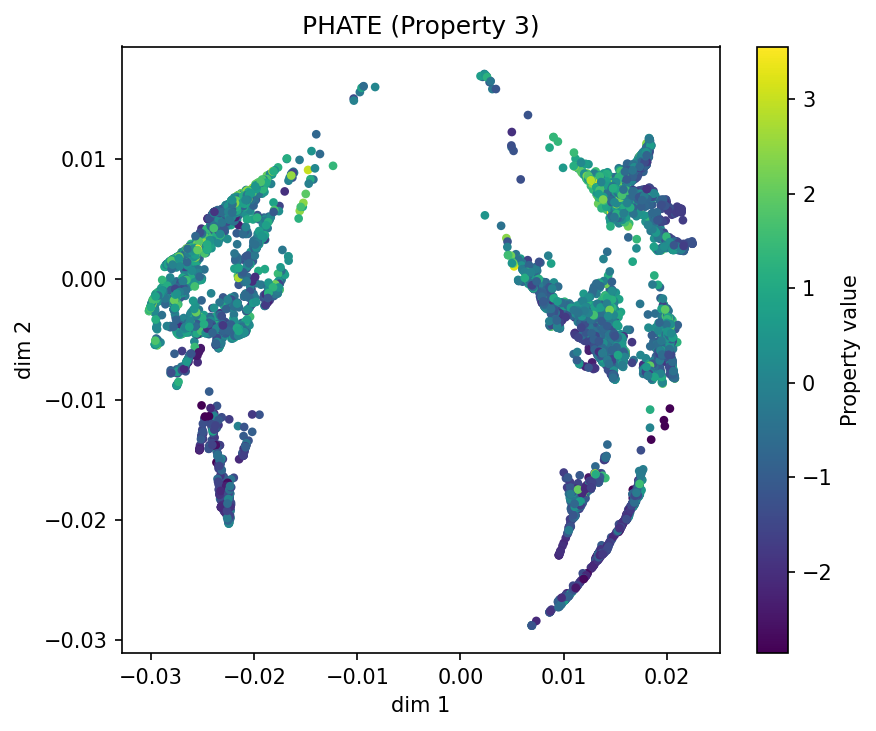


📊 latent_phate_prop4.png


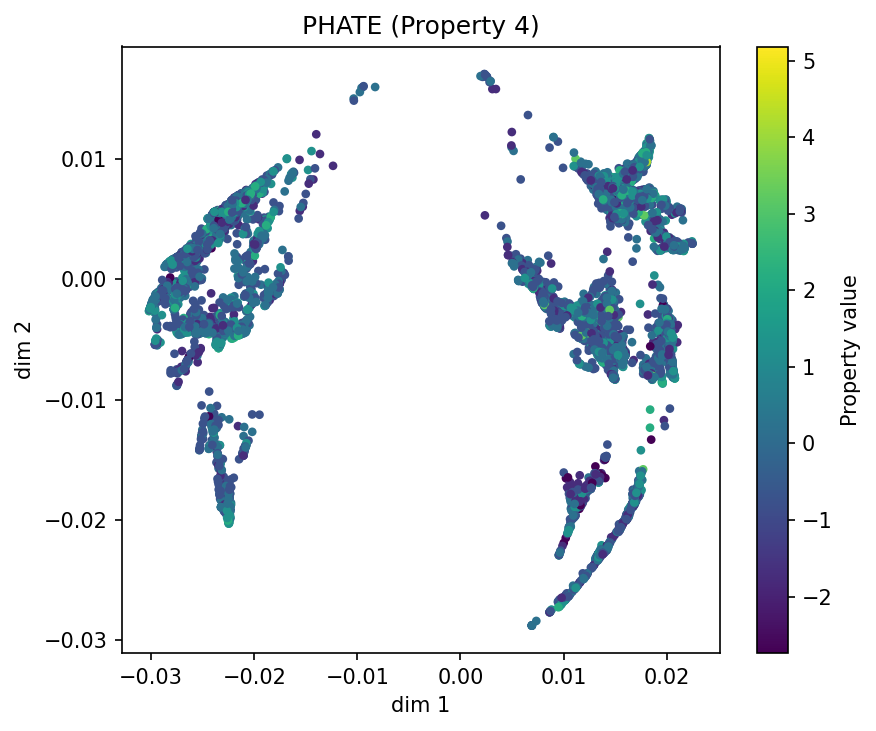

In [5]:
# Display the generated figures
from IPython.display import Image, display
import glob
from pathlib import Path

outdir = 'figs/zinc12k_evaluation_default'  # Match the outdir from visualization script
fig_files = sorted(glob.glob(f'{outdir}/*.png'))
if fig_files:
    print(f"Found {len(fig_files)} figure(s):\n")
    for fig_path in fig_files:
        print(f"📊 {Path(fig_path).name}")
        display(Image(fig_path))
        print()
else:
    print(f"No figures found in {outdir}")


## Atom Type Usage Statistics

This training run uses **14 node features** (8 atom types + 6 pair encodings) instead of the previous 10 features (4 atom types + 6 pairs).

### Atom Type Distribution in ZINC12K Dataset:

| Atom Type | Total Count | Molecules | % of Molecules |
|-----------|-------------|-----------|----------------|
| C         | 204,837     | 11,994    | 100.00%        |
| O         | 27,701      | 11,203    | 93.41%         |
| N         | 33,874      | 11,705    | 97.59%         |
| S         | 4,928       | 4,202     | 35.03%         |
| **F**     | **3,744**   | **2,231** | **18.60%**     |
| **Cl**    | **2,021**   | **1,720** | **14.34%**     |
| **Br**    | **596**     | **579**   | **4.83%**      |
| **I**     | **42**      | **42**    | **0.35%**      |

**Note:** The new atom types (F, Cl, Br, I) are relatively rare in the dataset, especially Iodine (only 42 molecules). This explains why the model improvement may be limited - the model has less training signal for these rare atom types.

**Node Feature Encoding:**
- Dimensions 0-7: One-hot encoding for C, O, N, S, F, Cl, Br, I
- Dimensions 8-13: Pair encodings (C-O, C-N, C-S, O-N, O-S, N-S)

In [5]:
## 3. Test Model Accuracy

import torch
import numpy as np
from models.GRASSY_model import GRASSY
from argparse import Namespace
from datasets.load_ZINC_tranche import ZINCDataset, Scattering
from tqdm import tqdm

# Load dataset
dataset = ZINCDataset('datasets/ZINC12K.npy', prop_stat_dict='datasets/ZINC12K_stats.npy',
                      transform=Scattering(scatter_model_name='scripts/trained_models/ZINC12K.npy'))

# Load model
model_path = 'scripts/final_logs/ZINC12K_regress_nokld_2025-12-31-20-31-47/ZINC12K_regress_nokld_model.npy'
model_state = torch.load(model_path, map_location='cpu')
sample_x, sample_y = dataset[0]

# Property names (adjust to match your dataset)
prop_names = ['qed', 'HeavyAtomMolWt', 'MolWt', 'BalabanJ', 'BertzCT', 'Ipc', 
              'TPSA', 'NumHAcceptors', 'NumHDonors', 'RingCount', 'MolLogP', 'SAscore', 'FSP3']

hparams = Namespace(input_dim=len(sample_x), bottle_dim=25, hidden_dim=100, 
                    learning_rate=0.001, alpha=0.01, beta=0.0, n_epochs=100,
                    len_epoch=None, batch_size=100, n_gpus=0, num_properties=len(sample_y))
model = GRASSY(hparams=hparams)
model.load_state_dict(model_state)
model.eval()

# Test set (last 1000 molecules: original test split)
test_indices = list(range(11000, len(dataset)))
print(f"Testing on {len(test_indices)} molecules (test set)")
print("=" * 70)

# Store all errors and true values per property
all_abs_errors = []
all_true_values = []

with torch.no_grad():
    for idx in tqdm(test_indices, desc="Evaluating"):
        x, y = dataset[idx]
        x_t = x.unsqueeze(0).float()
        y_t = torch.tensor(y).unsqueeze(0).float()
        
        _, y_hat, _, _, _ = model(x_t)
        
        # Absolute error per property
        abs_error = torch.abs(y_hat - y_t).squeeze(0)
        all_abs_errors.append(abs_error.numpy())
        all_true_values.append(y_t.squeeze(0).numpy())

# Convert to arrays: [N_samples, N_properties]
all_abs_errors = np.array(all_abs_errors)
all_true_values = np.array(all_true_values)

print("\n" + "=" * 70)
print("PROPERTY PREDICTION ACCURACY (Per Property)")
print("=" * 70)
print(f"{'Property':<20} | {'MAE':<12} | {'Std Dev':<12} | {'Range (min-max)':<20}")
print("-" * 70)

# Calculate and print stats per property
for i in range(all_abs_errors.shape[1]):
    prop_mae = all_abs_errors[:, i].mean()
    prop_std = all_abs_errors[:, i].std()
    prop_min = all_true_values[:, i].min()
    prop_max = all_true_values[:, i].max()
    
    # Use property name if available
    p_name = prop_names[i] if i < len(prop_names) else f"Prop {i+1}"
    
    print(f"{p_name:<20} | {prop_mae:<12.6f} | {prop_std:<12.6f} | [{prop_min:.3f}, {prop_max:.3f}]")

print("=" * 70)
print("\nOverall (averaged across all properties):")
print(f"  Mean Absolute Error: {all_abs_errors.mean():.6f}")
print(f"  Standard Deviation: ±{all_abs_errors.std():.6f}")

C:\Users\stolk\AppData\Local\Temp\ipykernel_74160\1609861007.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state = torch.load(model_path, map_location='cpu')


Testing on 994 molecules (test set)


Evaluating:   0%|          | 0/994 [00:00<?, ?it/s]C:\Users\stolk\AppData\Local\Temp\ipykernel_74160\1609861007.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_t = torch.tensor(y).unsqueeze(0).float()
Evaluating: 100%|██████████| 994/994 [00:24<00:00, 40.42it/s]


PROPERTY PREDICTION ACCURACY (Per Property)
Property             | MAE          | Std Dev      | Range (min-max)     
----------------------------------------------------------------------
qed                  | 0.707062     | 0.537593     | [-3.807, 1.531]
HeavyAtomMolWt       | 0.650904     | 0.537913     | [-2.830, 2.765]
MolWt                | 0.653018     | 0.537974     | [-2.814, 2.681]
BalabanJ             | 0.685646     | 0.676419     | [-1.910, 8.057]
BertzCT              | 0.688809     | 0.580503     | [-2.338, 3.906]
Ipc                  | 0.355819     | 1.151518     | [-0.210, 26.519]
TPSA                 | 0.478327     | 0.391411     | [-2.860, 3.558]
NumHAcceptors        | 0.566828     | 0.441293     | [-2.395, 3.028]
NumHDonors           | 0.719050     | 0.553077     | [-1.397, 3.149]
RingCount            | 0.692525     | 0.579919     | [-2.740, 3.207]
MolLogP              | 0.659983     | 0.555153     | [-4.678, 2.301]
SAscore              | 0.744186     | 0.588590    